<a href="https://colab.research.google.com/github/hclperera/Cat-Breed-Identification/blob/main/Model_v1_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Extract dataset from ZIP
drive_path = '/content/drive/MyDrive/Project/cats.zip'
extract_path = '/content/dataset'

if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully to /content/dataset")
else:
    print("Error: ZIP file not found in Drive. Check the file name.")

Mounted at /content/drive
Dataset extracted successfully to /content/dataset


In [ ]:
# Recreate Train/Val/Test Split

BATCH_SIZE = 32
IMG_SIZE = (180, 180)
data_dir = '/content/dataset/cat breeds'

print("Loading and Splitting Dataset into Train, Val, and Test...")

# Load the 20% validation split
initial_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # Original 20% split
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = initial_val_ds.class_names
print(f"Target Breeds: {class_names}")

# Split the 20% evenly into 10% Validation and 10% Testing
val_batches = tf.data.experimental.cardinality(initial_val_ds)
test_ds = initial_val_ds.take(val_batches // 2)
val_ds = initial_val_ds.skip(val_batches // 2)

print(f"Unseen Testing batches ready: {tf.data.experimental.cardinality(test_ds).numpy()}")

Loading and Splitting Dataset into Train, Val, and Test...
Found 7813 files belonging to 4 classes.
Using 1562 files for validation.
Target Breeds: ['Bombay', 'Calico', 'Persian', 'Siamese']
Unseen Testing batches ready: 24


Loading Implementation 1 model from: /content/drive/MyDrive/Project/model_v1.h5


Model v1 loaded successfully!

Evaluating model_v1 on the Unseen Test Dataset...

CLASSIFICATION REPORT - IMPLEMENTATION 1 (TEST DATA)
              precision    recall  f1-score   support

      Bombay       0.71      0.77      0.74       183
      Calico       0.56      0.53      0.54       203
     Persian       0.47      0.58      0.52       174
     Siamese       0.58      0.45      0.51       208

    accuracy                           0.58       768
   macro avg       0.58      0.58      0.58       768
weighted avg       0.58      0.58      0.58       768



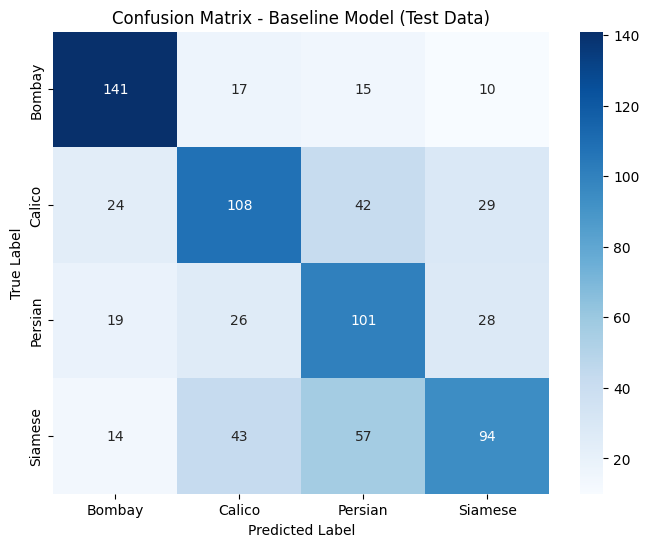

In [ ]:
# Load Model v1 and Evaluate

model_v1_path = '/content/drive/MyDrive/Project/model_v1.h5'

try:
    # Load the baseline model
    print(f"Loading Implementation 1 model from: {model_v1_path}")
    model_v1 = tf.keras.models.load_model(model_v1_path)
    print("Model v1 loaded successfully!\n")

    print("Evaluating model_v1 on the Unseen Test Dataset...")
    y_true_v1 = []
    y_pred_v1 = []

    # Extract true labels and predict
    for images, labels in test_ds:
        y_true_v1.extend(labels.numpy())
        preds_v1 = model_v1.predict(images, verbose=0)
        y_pred_v1.extend(np.argmax(preds_v1, axis=1))

    # 1. Classification Report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT - IMPLEMENTATION 1 (TEST DATA)")
    print("="*60)
    report = classification_report(y_true_v1, y_pred_v1, target_names=class_names)
    print(report)

    # 2. Confusion Matrix (Updated for Test Data)
    cm = confusion_matrix(y_true_v1, y_pred_v1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Baseline Model (Test Data)')
    plt.show()

except OSError:
    print(f"Error: Could not find the model at {model_v1_path}. Please check if the file exists.")